**Цель работы**
1. Изучить проблему высокой размерности данных и её влияние на анализ.
2. Освоить методы линейного и нелинейного снижения размерности.
3. Научиться выявлять скрытую структуру данных и интерпретировать
результаты преобразований.
4. Научиться интерпретировать новые признаки, полученные после
преобразования пространства признаков.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
import umap

# Загрузка данных
df = pd.read_csv('../data/Gaming_Academic_Performance.csv')

# Отбираем только числовые признаки для анализа, т.к PCA работает с числами
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols].copy()

# Проверка на пропуски если есть, заполним средним, чтобы не ломать матричные операции
if df_numeric.isnull().sum().sum() > 0:
    df_numeric.fillna(df_numeric.mean(), inplace=True)

print("Числовые признаки:", numeric_cols.tolist())
print("Размерность данных:", df_numeric.shape)

Числовые признаки: ['student_id', 'age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'grades']
Размерность данных: (8000, 11)


# Задание 1. Геометрия данных в пространстве признаков
Используйте датасет с числовыми признаками
1. Определите:
- число объектов
- число признаков
2. Постройте:
- гистограммы распределения признаков;
- матрицу корреляций признаков.
3. Ответьте на вопросы:
- Есть ли сильно коррелированные признаки?
- Можно ли предположить, что часть признаков содержит избыточную
информацию?

Число объектов: 8000
Число признаков: 11


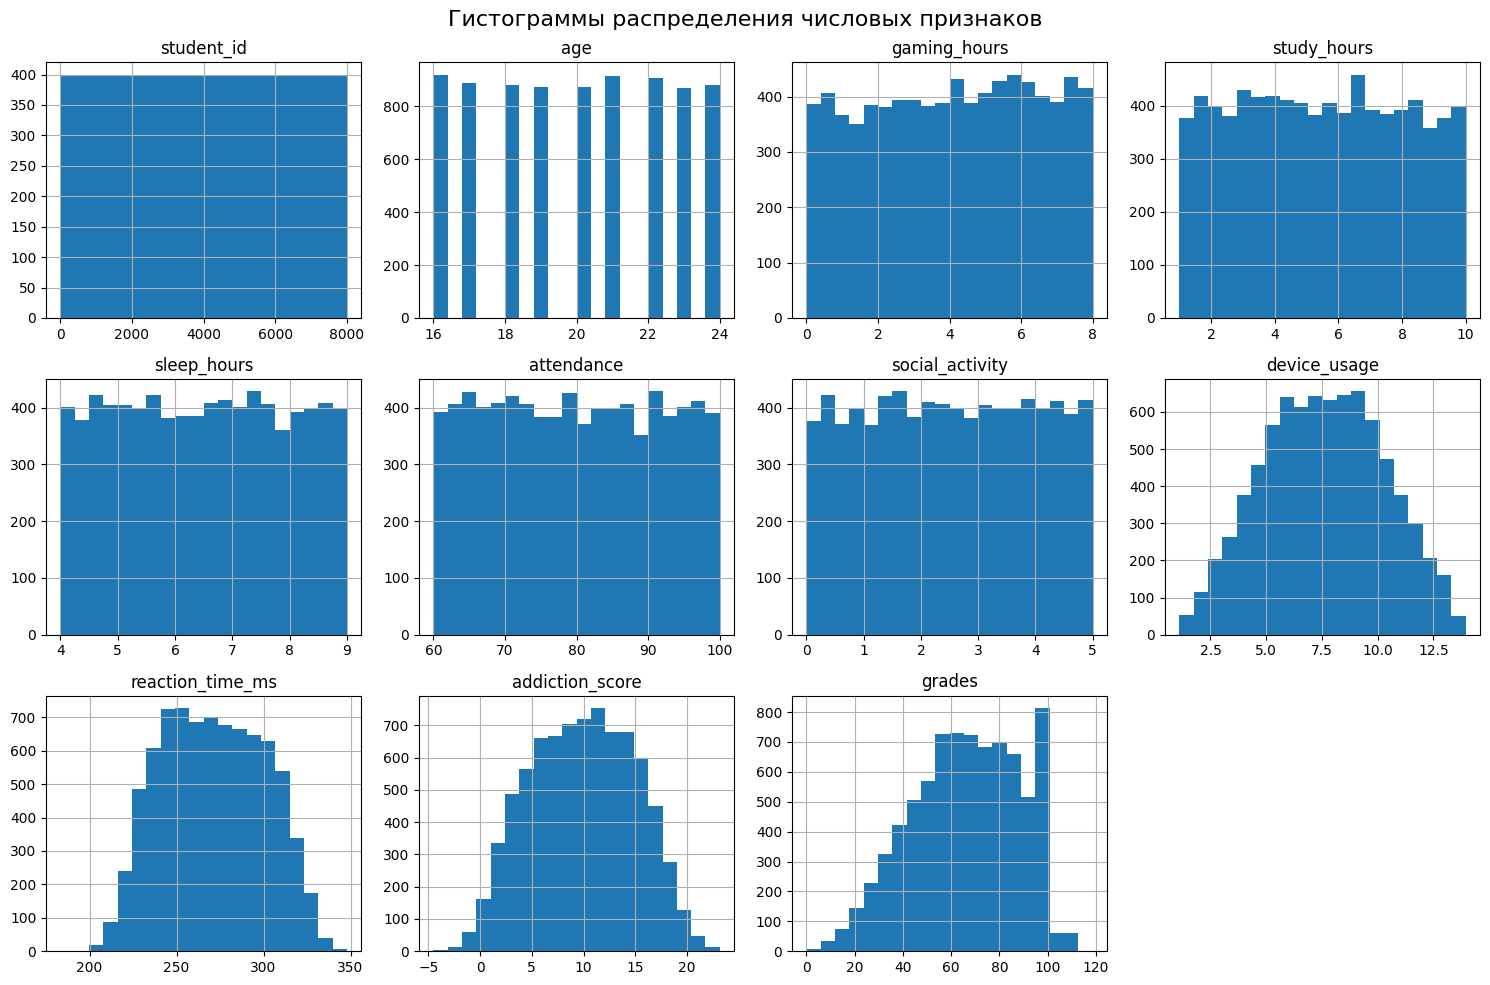

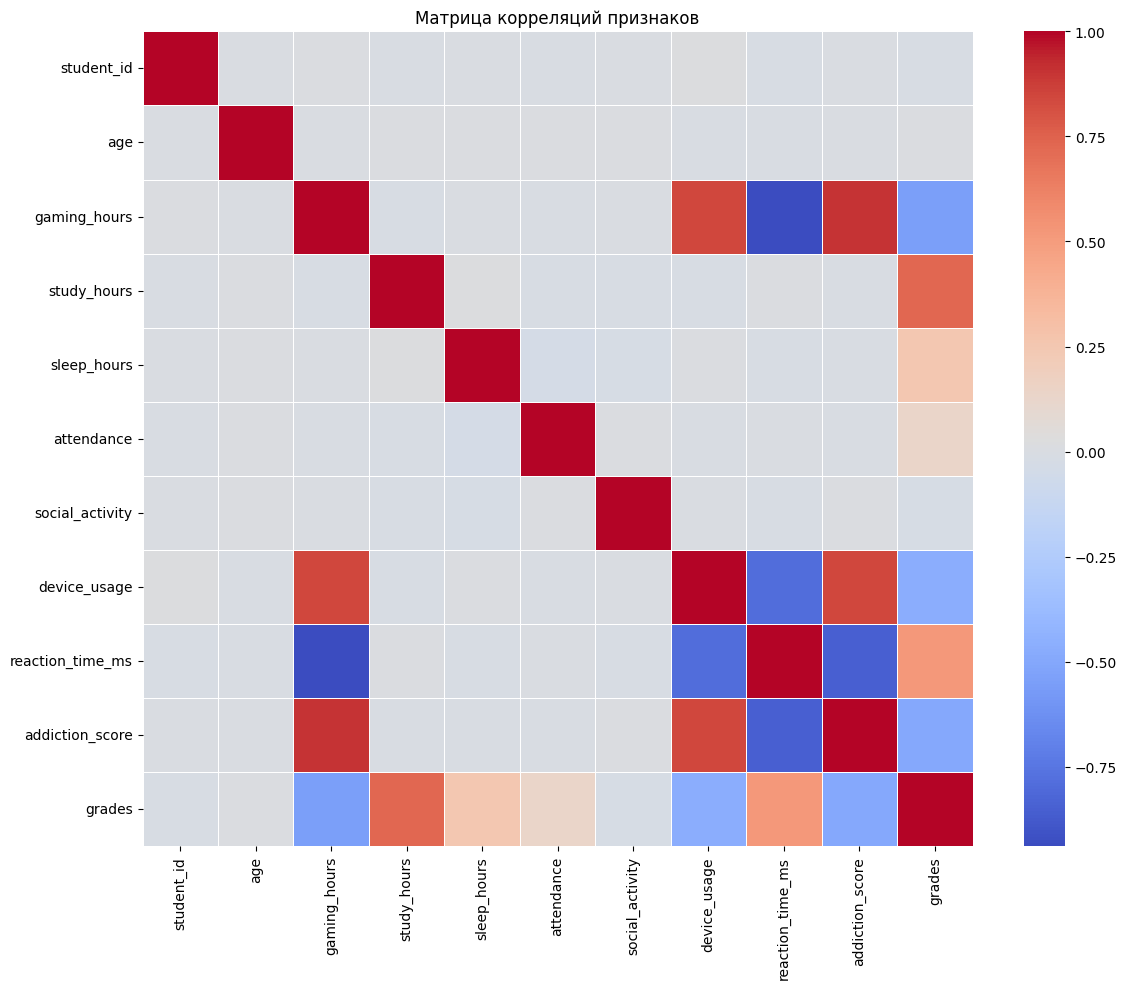


Сильно коррелированные признаки (|corr| > 0.7):
device_usage и gaming_hours: 0.848
reaction_time_ms и gaming_hours: -0.939
reaction_time_ms и device_usage: -0.791
addiction_score и gaming_hours: 0.909
addiction_score и device_usage: 0.847
addiction_score и reaction_time_ms: -0.850
grades и study_hours: 0.733

Наличие корреляций указывает на то, что часть признаков содержит избыточную информацию.


In [18]:
# Определите число объектов и число признаков
n_objects, n_features = df_numeric.shape
print(f"Число объектов: {n_objects}")
print(f"Число признаков: {n_features}")

# Гистограммы распределения признаков
df_numeric.hist(bins=20, figsize=(15, 10), layout=(3, 4))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Матрица корреляций признаков
plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

# Пары с высокой корреляцией
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            high_corr_pairs.append((col1, col2, correlation_matrix.iloc[i, j]))

print("\nСильно коррелированные признаки (|corr| > 0.7):")
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} и {pair[1]}: {pair[2]:.3f}")
else:
    print("Сильно коррелированных пар (>0.7) не обнаружено.")

# Если есть высокая корреляция, значит, признаки содержат избыточную информацию.
print("\nНаличие корреляций указывает на то, что часть признаков содержит избыточную информацию.")

# Задание 2. Реализация PCA
Реализуйте алгоритм PCA с нуля, используя только библиотеку NumPy.    
Алгоритм должен включать:
1. Стандартизацию данных.
Используйте датасет с числовыми признаками
2. Вычисление ковариационной матрицы.
3. Нахождение собственных значений и собственных векторов.
4. Сортировку компонент по убыванию собственных значений.
5. Проекцию данных на первые k компонент.    
 
Сравните результат с реализацией:       
sklearn.decomposition.PCA      

In [20]:
class PCAself:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None
        self.values = None

    def fit(self, X):
        # Стандартизация данных
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Вычисление ковариационной матрицы
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # Нахождение собственных значений и собственных векторов
        values, vectors = np.linalg.eigh(cov_matrix)

        # Сортировка компонент по убыванию собственных значений
        # np.linalg.eigh возвращает отсортированные по возрастанию, поэтому переворачиваем
        idx = np.argsort(values)[::-1]
        values = values[idx]
        vectors = vectors[:, idx]
        
        self.values = values
        
        # Сохраняем первые n_components собственных векторов
        self.components = vectors[:, :self.n_components]

        # Доля объясненной дисперсии
        total_variance = np.sum(values)
        self.explained_variance_ratio_ = values[:self.n_components] / total_variance
        
        return self

    def transform(self, X):
        # Проекция данных на первые k компонент
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X_transformed):
        # Восстановление данных
        return np.dot(X_transformed, self.components.T) + self.mean
    
# Подготовка данных для PCA
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# Oпределим оптимальное число компонент через sklearn для полного анализа
pca_sklearn_full = SklearnPCA()
pca_sklearn_full.fit(data_scaled)

# Для сравнения качества возьмем k=2
k_test = 2
pca_slf = PCAself(n_components=k_test)
data_pca_slf = pca_slf.fit_transform(data_scaled)

pca_sklearn_2 = SklearnPCA(n_components=k_test)
data_pca_sklearn = pca_sklearn_2.fit_transform(data_scaled)

# Сравнение результатов (первые 5 строк)
print("\nСравнение первых 5 строк проекции (self vs Sklearn):")
print("self:\n", data_pca_slf[:5] * -1)
print("Sklearn:\n", data_pca_sklearn[:5])
# Примечание: знаки могут отличаться, так как направление собственного вектора не определено однозначно, "домножил на -1 для корректного сравнения, abs значения совпадают"
# но абсолютные значения и структура должны совпадать.


Сравнение первых 5 строк проекции (self vs Sklearn):
self:
 [[ 1.49157475  2.23367013]
 [-3.79863018  0.84675365]
 [-2.47765454  0.81262311]
 [ 2.73170534 -0.99374422]
 [ 1.074569   -0.026037  ]]
Sklearn:
 [[ 1.49157475  2.23367013]
 [-3.79863018  0.84675365]
 [-2.47765454  0.81262311]
 [ 2.73170534 -0.99374422]
 [ 1.074569   -0.026037  ]]


### 2.1 Исследование
Постройте график:
- доля объяснённой дисперсии
- накопленная объяснённая дисперсия

Ответьте:
1. Сколько компонент объясняют 80% дисперсии?
2. Сколько компонент объясняют 95% дисперсии?

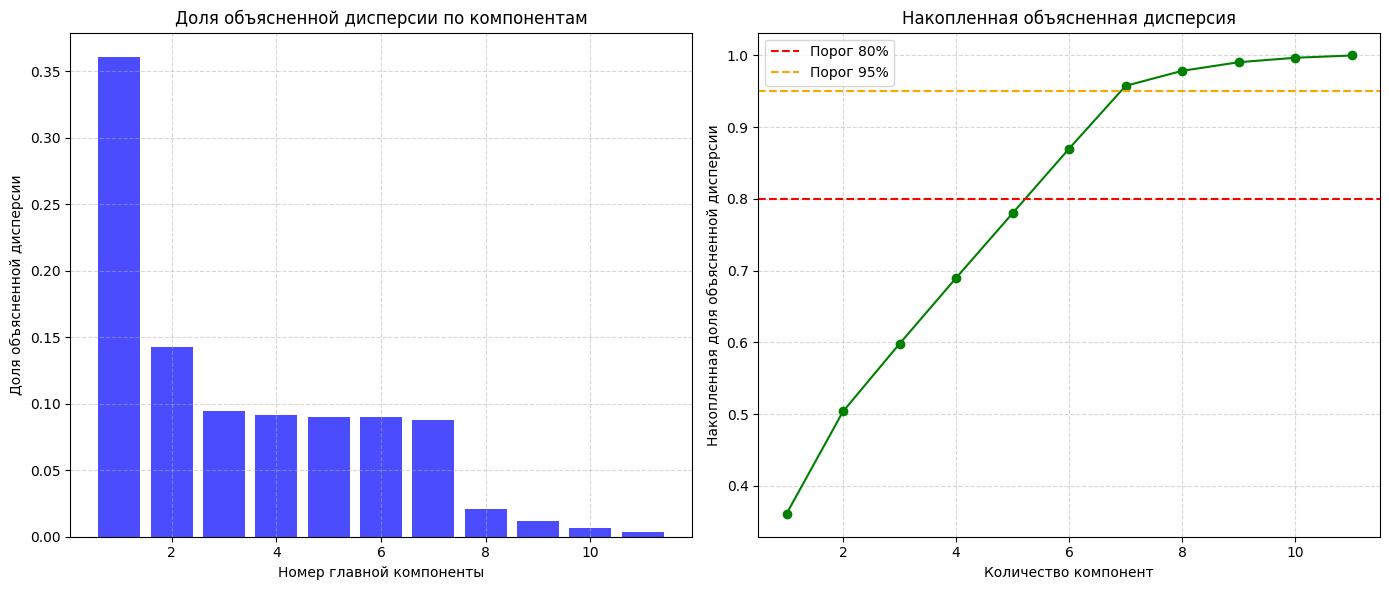


Задание 2.1
Компонент для 80% дисперсии: 6
Компонент для 95% дисперсии: 7


In [21]:
# График доли и накопленной дисперсии
explained_variance = pca_sklearn_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Доля объясненной дисперсии каждой компоненты
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='blue')
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Доля объясненной дисперсии')
axes[0].set_title('Доля объясненной дисперсии по компонентам')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Накопленная объясненная дисперсия
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='green')
axes[1].axhline(y=0.80, color='r', linestyle='--', label='Порог 80%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='Порог 95%')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Накопленная доля объясненной дисперсии')
axes[1].set_title('Накопленная объясненная дисперсия')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ответы на вопросы 2.1:
n_comp_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nЗадание 2.1")
print(f"Компонент для 80% дисперсии: {n_comp_80}")
print(f"Компонент для 95% дисперсии: {n_comp_95}")

# Задание 3. Интерпретация главных компонент
Рассмотрите первые три главные компоненты.
1. Определите коэффициенты признаков в каждой компоненте
2. Найдите признаки с наибольшим вкладом

Ответьте:
1. Какие признаки больше всего влияют на первую компоненту?
2. Можно ли интерпретировать первую компоненту как некоторую
комбинацию исходных признаков?
3. Есть ли признаки, которые практически не влияют на первые компоненты?

In [23]:
pca_interpret = SklearnPCA(n_components=3)
components = pca_interpret.fit_transform(data_scaled)

# Коэффициенты признаков
loadings = pd.DataFrame(
    pca_interpret.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=df_numeric.columns
)

print("Веса признаков в первых трех главных компонентах:")
print(loadings)

# 1. Какие признаки больше всего влияют на первую компоненту?
pc1_top_features = loadings['PC1'].abs().sort_values(ascending=False).head(3)
print(f"\nТоп-3 признака, влияющих на PC1: {pc1_top_features.index.tolist()}")
print("Их веса:")
print(pc1_top_features)

# 2. Можно ли интерпретировать первую компоненту?
# Посмотрим на знаки весов. Если, например, gaming_hours имеет большой положительный вес, 
# а grades большой отрицательный, то PC1 можно интерпретировать как "Конфликт между играми и учебой".
print("\nИнтерпретация PC1:")
print("Если признаки с наибольшим весом имеют противоположные знаки, это указывает на компромисс между ними.")
print("Например, если 'gaming_hours' (+) и 'grades' (-), то PC1 отражает негативное влияние игр на успеваемость.")

# 3. Есть ли признаки, которые практически не влияют?
low_impact_features = loadings.abs().mean(axis=1).sort_values().head(3)
print(f"\nПризнаки с наименьшим влиянием на первые 3 компоненты: {low_impact_features.index.tolist()}")

Веса признаков в первых трех главных компонентах:
                       PC1       PC2       PC3
student_id        0.007927 -0.007234 -0.097997
age              -0.000018  0.029517  0.190779
gaming_hours      0.483082  0.136060  0.007042
study_hours      -0.090880  0.720150  0.091177
sleep_hours      -0.026733  0.270184 -0.536869
attendance       -0.015503  0.101987  0.668330
social_activity   0.007410 -0.033252  0.457884
device_usage      0.449989  0.148204 -0.000752
reaction_time_ms -0.466491 -0.137665 -0.004802
addiction_score   0.467076  0.152136  0.013993
grades           -0.345016  0.559804  0.029440

Топ-3 признака, влияющих на PC1: ['gaming_hours', 'addiction_score', 'reaction_time_ms']
Их веса:
gaming_hours        0.483082
addiction_score     0.467076
reaction_time_ms    0.466491
Name: PC1, dtype: float64

Интерпретация PC1:
Если признаки с наибольшим весом имеют противоположные знаки, это указывает на компромисс между ними.
Например, если 'gaming_hours' (+) и 'grades' (-), то

# Задание 4. Визуализация данных
Постройте:
1. визуализацию по двум исходным признакам;
2. визуализацию по двум главным компонентам.

Сравните:
- структуру распределения объектов;
- наличие групп или закономерностей.

Ответьте:
1. Улучшилась ли визуализация после PCA?
2. Почему в пространстве главных компонент структура может быть заметнее?

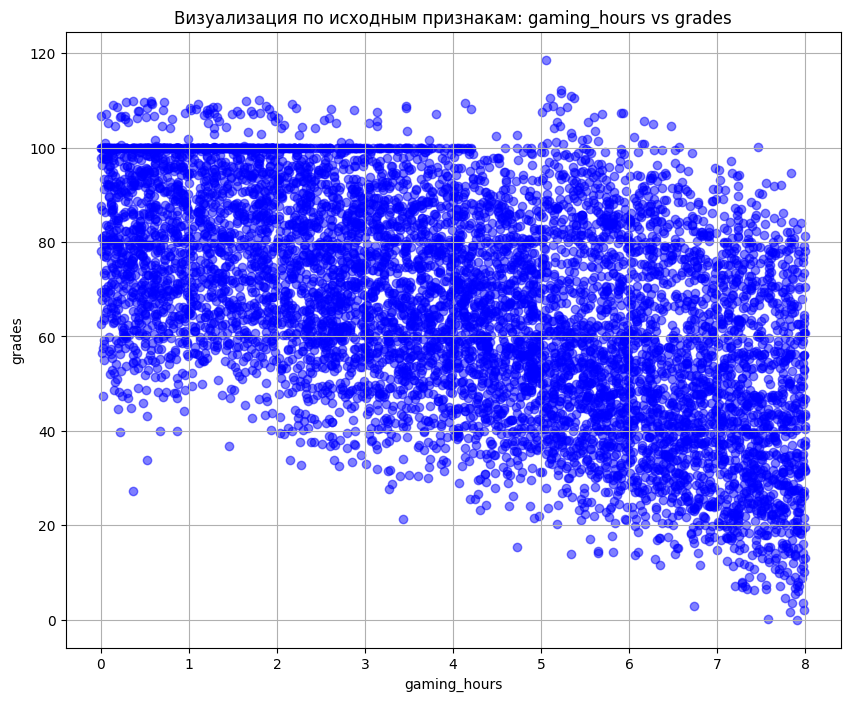

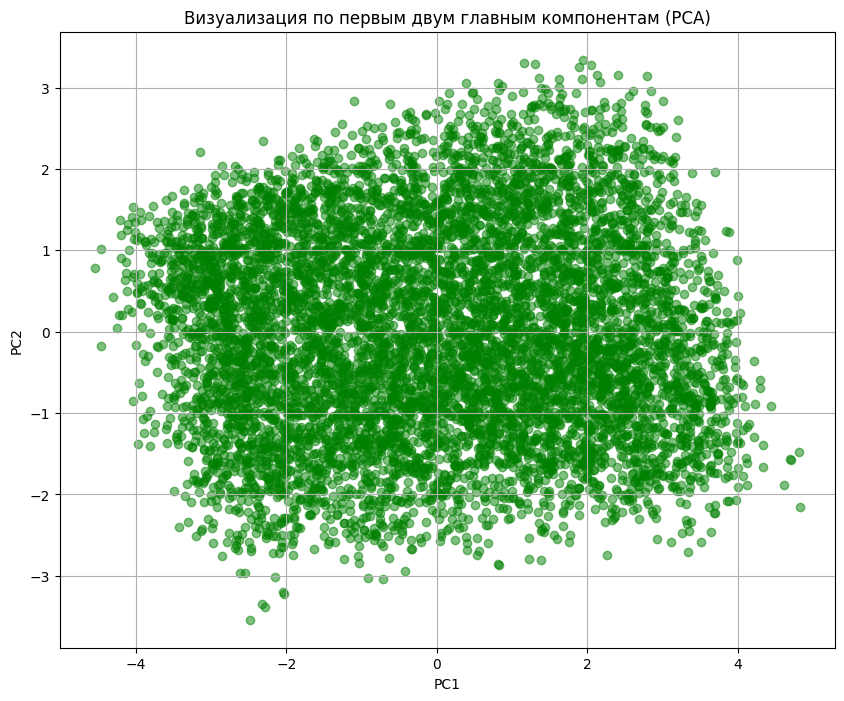

In [24]:
feat1, feat2 = 'gaming_hours', 'grades'

# Визуализация по двум исходным признакам
plt.figure(figsize=(10, 8))
plt.scatter(df_numeric[feat1], df_numeric[feat2], c='blue', alpha=0.5)
plt.title(f'Визуализация по исходным признакам: {feat1} vs {feat2}')
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.grid(True)
plt.show()

# Визуализация по двум главным компонентам
plt.figure(figsize=(10, 8))
plt.scatter(data_pca_sklearn[:, 0], data_pca_sklearn[:, 1], c='green', alpha=0.5)
plt.title('Визуализация по первым двум главным компонентам (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

### Ответы
1. PCA позволяет увидеть структуру данных в пространстве максимальной дисперсии. Если в исходных признаках группы были перекрыты шумом, в PCA они могут стать заметнее.
2. Потому что PC1 и PC2 отсекают шумовые признаки и оставляют направления, где разброс данных максимален.

# Задание 5. Нелинейные методы снижения размерности
Используйте два метода:
- t-SNE
- UMAP   

Постройте двумерные проекции данных.

### 5.1 Исследование параметров      
Для t-SNE измените параметр:     
perplexity = 5, 30, 50      
Для UMAP измените:     
n_neighbors    
min_dist    
Постройте несколько визуализаций.     


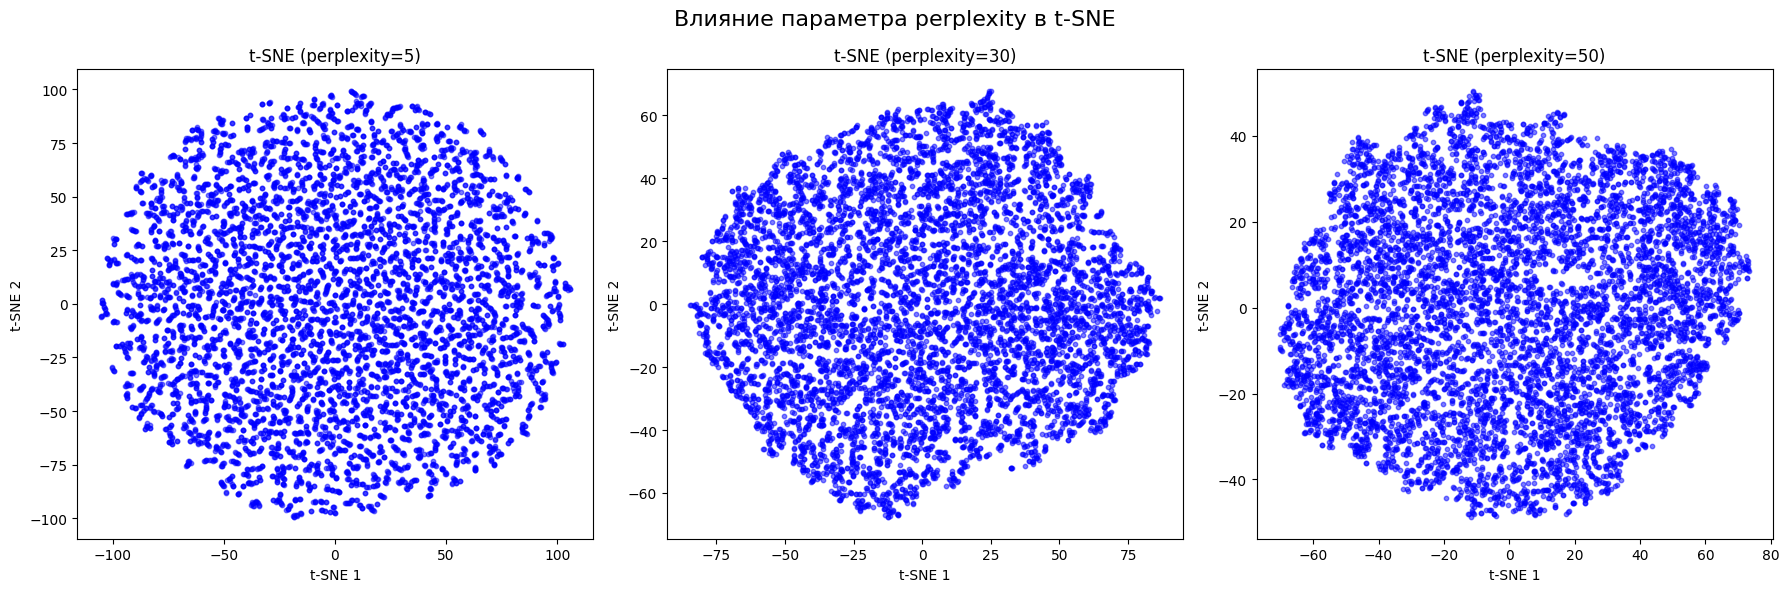

UMAP: Standart (15, 0.1)...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: Global (50, 0.5)...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: Local (5, 0.01)...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


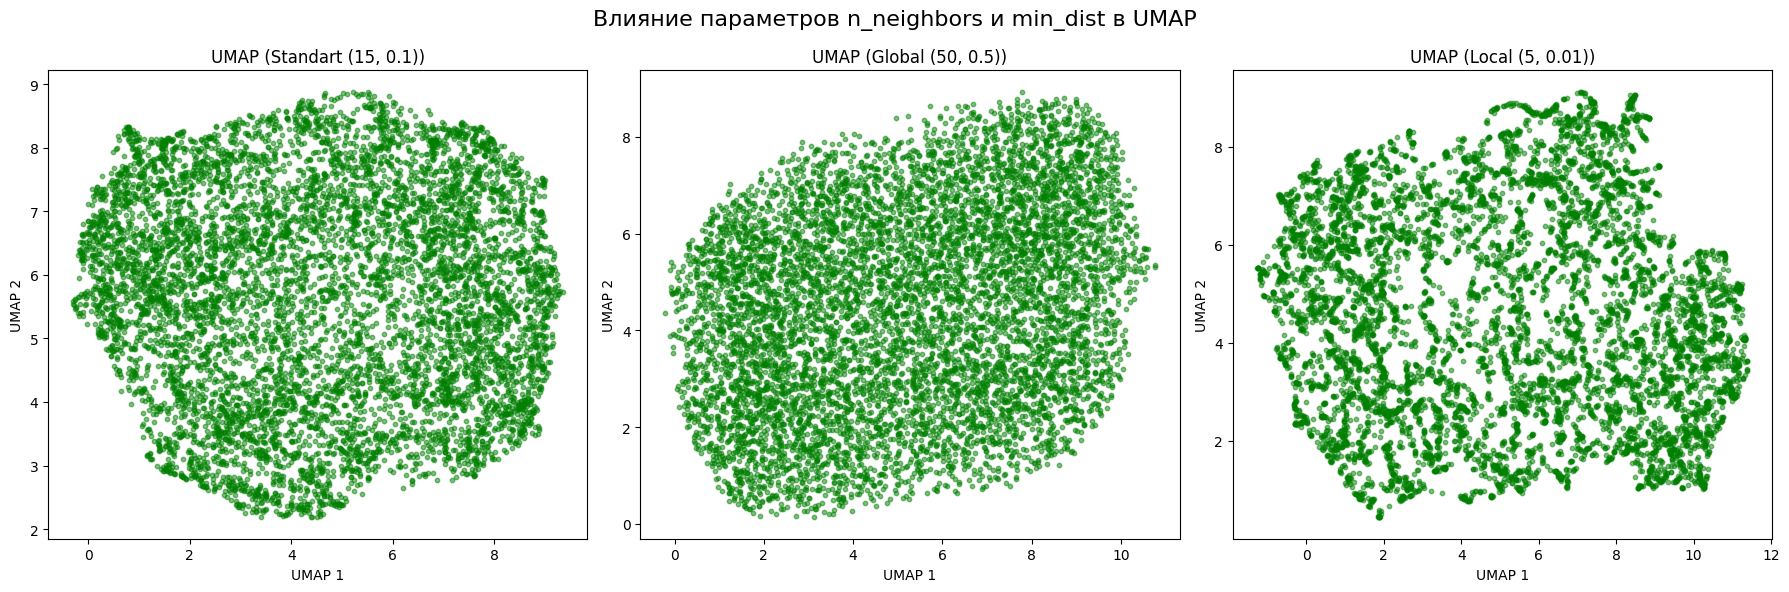

In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# t-SNE с разными perplexity
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    data_tsne = tsne.fit_transform(data_scaled)
    
    axes[i].scatter(data_tsne[:, 0], data_tsne[:, 1], alpha=0.5, s=10, c='blue')
    axes[i].set_title(f't-SNE (perplexity={perp})')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

plt.suptitle('Влияние параметра perplexity в t-SNE', fontsize=16)
plt.tight_layout()
plt.show()

# UMAP с разными параметрами (n_neighbors и min_dist)
umap_params = [
    {'n_neighbors': 15, 'min_dist': 0.1, 'label': 'Standart (15, 0.1)'},
    {'n_neighbors': 50, 'min_dist': 0.5, 'label': 'Global (50, 0.5)'},
    {'n_neighbors': 5, 'min_dist': 0.01, 'label': 'Local (5, 0.01)'}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, params in enumerate(umap_params):
    print(f"UMAP: {params['label']}...")
    umap_model = umap.UMAP(
        n_neighbors=params['n_neighbors'], 
        min_dist=params['min_dist'], 
        n_components=2, 
        random_state=42
    )
    data_umap = umap_model.fit_transform(data_scaled)
    
    axes[i].scatter(data_umap[:, 0], data_umap[:, 1], alpha=0.5, s=10, c='green')
    axes[i].set_title(f"UMAP ({params['label']})")
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')

plt.suptitle('Влияние параметров n_neighbors и min_dist в UMAP', fontsize=16)
plt.tight_layout()
plt.show()

Ответьте:
1. Как меняется структура данных при разных параметрах?
2. Какой метод даёт наиболее интерпретируемую визуализацию?
3. Почему результаты разных методов могут существенно отличаться?

### Ответы
1. t-SNE чувствителен к perplexity
2. UMAP лучше сохраняет глобальную структуру
3. Методы дают разные результаты из-за разной математики


# Задание 6. Исследование степени сжатия данных
Одной из ключевых задач методов снижения размерности является сжатие
данных с минимальной потерей информации.     
Метод главных компонент (PCA) позволяет представить данные в пространстве
меньшей размерности, однако при этом часть информации неизбежно теряется.       
В этом задании необходимо экспериментально исследовать, как уменьшение
числа компонент влияет на точность восстановления исходных данных.

### 6.1 Снижение размерности
В выбранном датасете с помощью PCA последовательно уменьшайте
размерность пространства признаков.     
Рассмотрите несколько вариантов числа компонент:
- k = 2
- k = 5
- k = 10
- k = 15    
(если исходных признаков меньше — используйте максимально возможное
значение).
Для каждого значения k:
1. обучите модель PCA;
2. преобразуйте исходные данные в пространство из k компонент.

### 6.2 Восстановление данных
После снижения размерности попробуйте восстановить исходные данные.     
Для этого необходимо выполнить обратное преобразование PCA.     
Полученные данные будут приближённой реконструкцией исходного датасета.     
Таким образом, для каждого значения k у вас будет:
- исходная матрица данных
- восстановленная матрица данных

### 6.3 Оценка ошибки восстановления 
Оцените, насколько восстановленные данные отличаются от исходных.      
Используйте среднеквадратичную ошибку (MSE):
- между исходными данными
- восстановленными данными
      
Для каждого значения k вычислите:    
MSE(original_data, reconstructed_data)      
Результаты оформите в виде таблицы

# 6.4 Визуальный анализ 
Постройте график зависимости:     
ошибка восстановления vs число компонент

Проанализируйте форму графика      
Обратите внимание:
- как быстро уменьшается ошибка;
- есть ли точка, после которой уменьшение ошибки становится
незначительным.

k=2: MSE = 0.4962
k=5: MSE = 0.2199
k=7: MSE = 0.0423
k=10: MSE = 0.0032
k=11: MSE = 0.0000

Таблица ошибок восстановления:
 Число компонент  Ошибка восстановления (MSE)
               2                 4.962398e-01
               5                 2.199055e-01
               7                 4.232877e-02
              10                 3.186122e-03
              11                 4.442739e-31


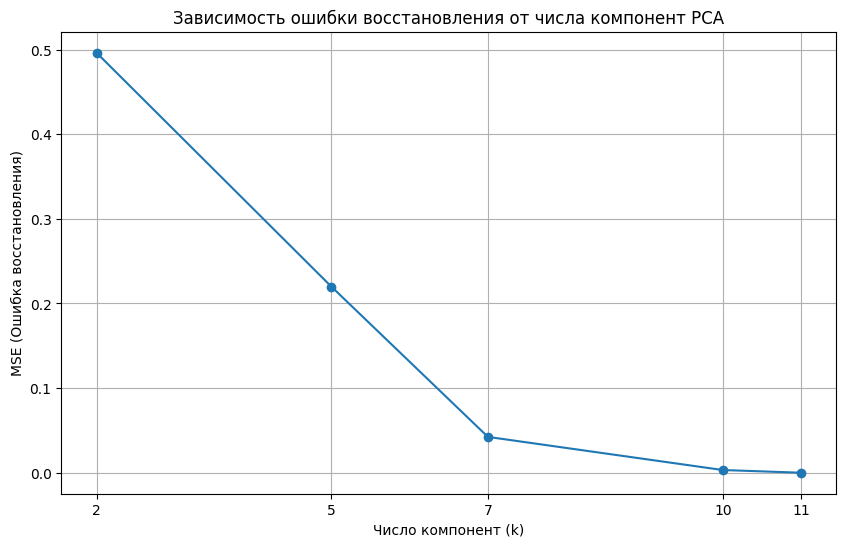

In [29]:
k_values = [2, 5, 7, 10, 11]
mse_results = []

for k in k_values:
    # обучение PCA(6.1)
    pca_temp = SklearnPCA(n_components=k)
    data_transformed = pca_temp.fit_transform(data_scaled)
    
    # Восстанавливаем данные(6.2)
    data_reconstructed = pca_temp.inverse_transform(data_transformed)
    
    # Оценка ошибки (MSE)(6.3)
    mse = np.mean((data_scaled - data_reconstructed) ** 2)
    mse_results.append(mse)
    print(f"k={k}: MSE = {mse:.4f}")

# Таблица результатов
results_df = pd.DataFrame({
    'Число компонент': k_values,
    'Ошибка восстановления (MSE)': mse_results
})
print("\nТаблица ошибок восстановления:")
print(results_df.to_string(index=False))

# Визуальный анализ(6.4)
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_results, marker='o', linestyle='-')
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE (Ошибка восстановления)')
plt.title('Зависимость ошибки восстановления от числа компонент PCA')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 6.5 Интерпретация результатов
Ответьте на следующие вопросы:
1. Почему при малом числе компонент ошибка восстановления большая?
2. Почему увеличение числа компонент уменьшает ошибку?
3. Можно ли полностью восстановить исходные данные при использовании
всех компонент?
4. Как это связано с объяснённой дисперсией PCA?
5. Как можно определить разумное число компонент, при котором данные уже
хорошо описаны, но размерность существенно меньше?

### Ответы 
1. Потому что мы отбрасываем компоненты с наибольшей дисперсией, теряя значительную часть информации о структуре данных.
2. Мы добавляем обратно направления, которые описывают все более тонкие детали разброса данных.
3. Да, если k равно числу исходных признаков, MSE будет равно 0 (с точностью до вычислительной погрешности).
4. MSE прямо пропорционально сумме дисперсий отброшенных компонент. Чем выше объяснённая дисперсия оставшихся компонент, тем ниже MSE.
5. Используют 'локоть' на графике накопленной дисперсии или задают порог (например, 95% дисперсии).

# Задание 7. Итоговый анализ
На основе проведённых экспериментов сформулируйте выводы.     
Ответьте на следующие вопросы:
1. Какую роль играет снижение размерности в анализе данных?
2. Всегда ли уменьшение размерности полезно?
3. В каких случаях линейные методы могут работать хуже нелинейных?
4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?

1. Роль снижения размерности:
   - Уменьшение шума и избыточности данных.
   - Ускорение работы алгоритмов машинного обучения.
   - Визуализация многомерных данных в 2D/3D.

2. Всегда ли уменьшение размерности полезно?
   - Нет. Если данные уже имеют низкую размерность или важны мелкие детали, которые отбрасываются, 
     это может ухудшить качество модели (потеря информации).

3. Когда линейные методы работают хуже нелинейных?
   - Когда данные имеют сложную нелинейную структуру.
     PCA не сможет развернуть такую структуру, а t-SNE/UMAP справятся лучше.

4. Преимущества и ограничения:
   - PCA: 
     - +Быстрый, детерминированный, сохраняет глобальную структуру.
     - -Линейный, плохо работает с нелинейными зависимостями.
   - t-SNE: 
     - +Отлично выделяет локальные кластеры.
     - -Медленный, стохастический, трудно интерпретировать расстояния между кластерами.
   - UMAP: 
     - +Быстрее t-SNE, лучше сохраняет глобальную структуру.
     - -Требует подбора параметров (n_neighbors, min_dist).